# Explorar datos a nivel de establecimiento educativo

Objetivos

- Analizar relación entre las variables que caracterizan a los establecimientos
- Identificar casos outliers para revisar pre-procesamiento de los datos

Datos utilizados:

- Puntajes SIMCE matemáticas 2do medio (2024)
- Características de los docentes (2025)
- Indicadores de desarrollo personal y social (2024)

## Cargar librerías y datos


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
path = '/Users/vcanalesg/Documents/diplomado_dcc/0_taller_proyecto/datos'
rbd = pd.read_parquet(path + '/rbd_consolidado.parquet')

## Exploración básica de los datos

- Dimensiones del dataset
- Listado de variables
- Conteo de casos perdidos (pendiente)

In [23]:
print('El dataset tiene ' + str(rbd.shape[0]) + ' establecimientos de educación y ' + str(rbd.shape[1]) + ' variables.')

# list(rbd.columns)

El dataset tiene 3000 establecimientos de educación y 160 variables.


## Selección de establecimiento a analizar

No todos los establecimientos tienen puntajes Simce de matemáticas válidos. Esto ocurre por diversos motivos:
- No tienen valor en el promedio del establecimiento (esto podría haberse dado porque el número de estudiantes es muy pequeño).
- El promedio se presenta, pero está marcado como no representativo del desempeño de los estudiantes por factores ajenos a la Agencia.


In [35]:
# marca_mate2m_rbd tiene valor NA cuando el puntaje es válido
# prom_mate2m_rbd corresponde al promedio simce del establecimiento.
rbd_filtrado = rbd[rbd['marca_mate2m_rbd'].isna() | (rbd['prom_mate2m_rbd'].isna() == False)]

# solo establecimientos con GSE bajo y medio-bajo
rbd_gse_medio_bajo = rbd_filtrado[rbd_filtrado['cod_grupo'].isin([2,3])]

## Análisis de asociación de variables

Revisar relación entre indicadores de desarrollo personal y social y los puntajes Simce para 2do medio.

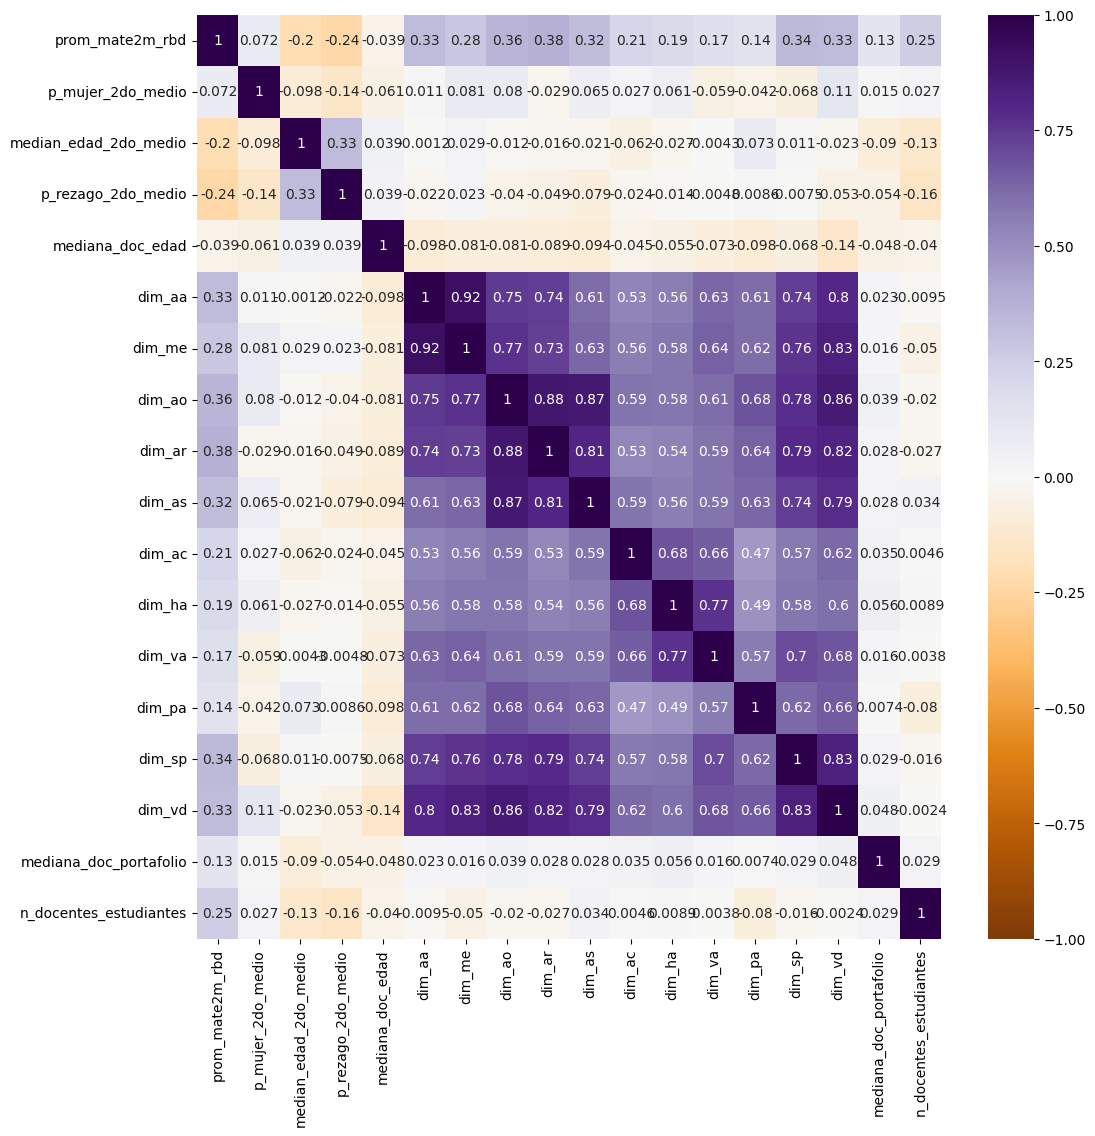

In [36]:
# Variables a considerar:
# prom_mate2m_rbd: promedio simce del establecimiento
# p_mujer_2do_medio: porcentaje de mujeres matriculadas en 2do medio
# median_edad_2do_medio: mediana de edad para matriculados 2do medio
# p_rezago_2do_medio: porcentaje de rezagados
# ind_am: autoestima académica y motivación escolar
# ind_cc: clima de convivencia escolar
# ind_hv: participación y formación ciudadana
# ind_pf: hábitos de vida saludable
# mediana_doc_edad: mediana de edad de los docentes de 2do medio
# n_docentes_rbd: número de docentes
# n_matricula_2do_medio: número de matriculados

variables = ['prom_mate2m_rbd', 'p_mujer_2do_medio', 'median_edad_2do_medio', 'p_rezago_2do_medio','mediana_doc_edad',
             'dim_aa','dim_me', 'dim_ao','dim_ar', 'dim_as','dim_ac', 'dim_ha', 'dim_va', 'dim_pa', 'dim_sp', 'dim_vd',
             'mediana_doc_portafolio', 'n_docentes_estudiantes']

plt.figure(figsize = (12, 12))

sns.heatmap(rbd_gse_medio_bajo[variables].corr(),
            annot=True,
            vmin=-1, vmax=1,
            cmap='PuOr');




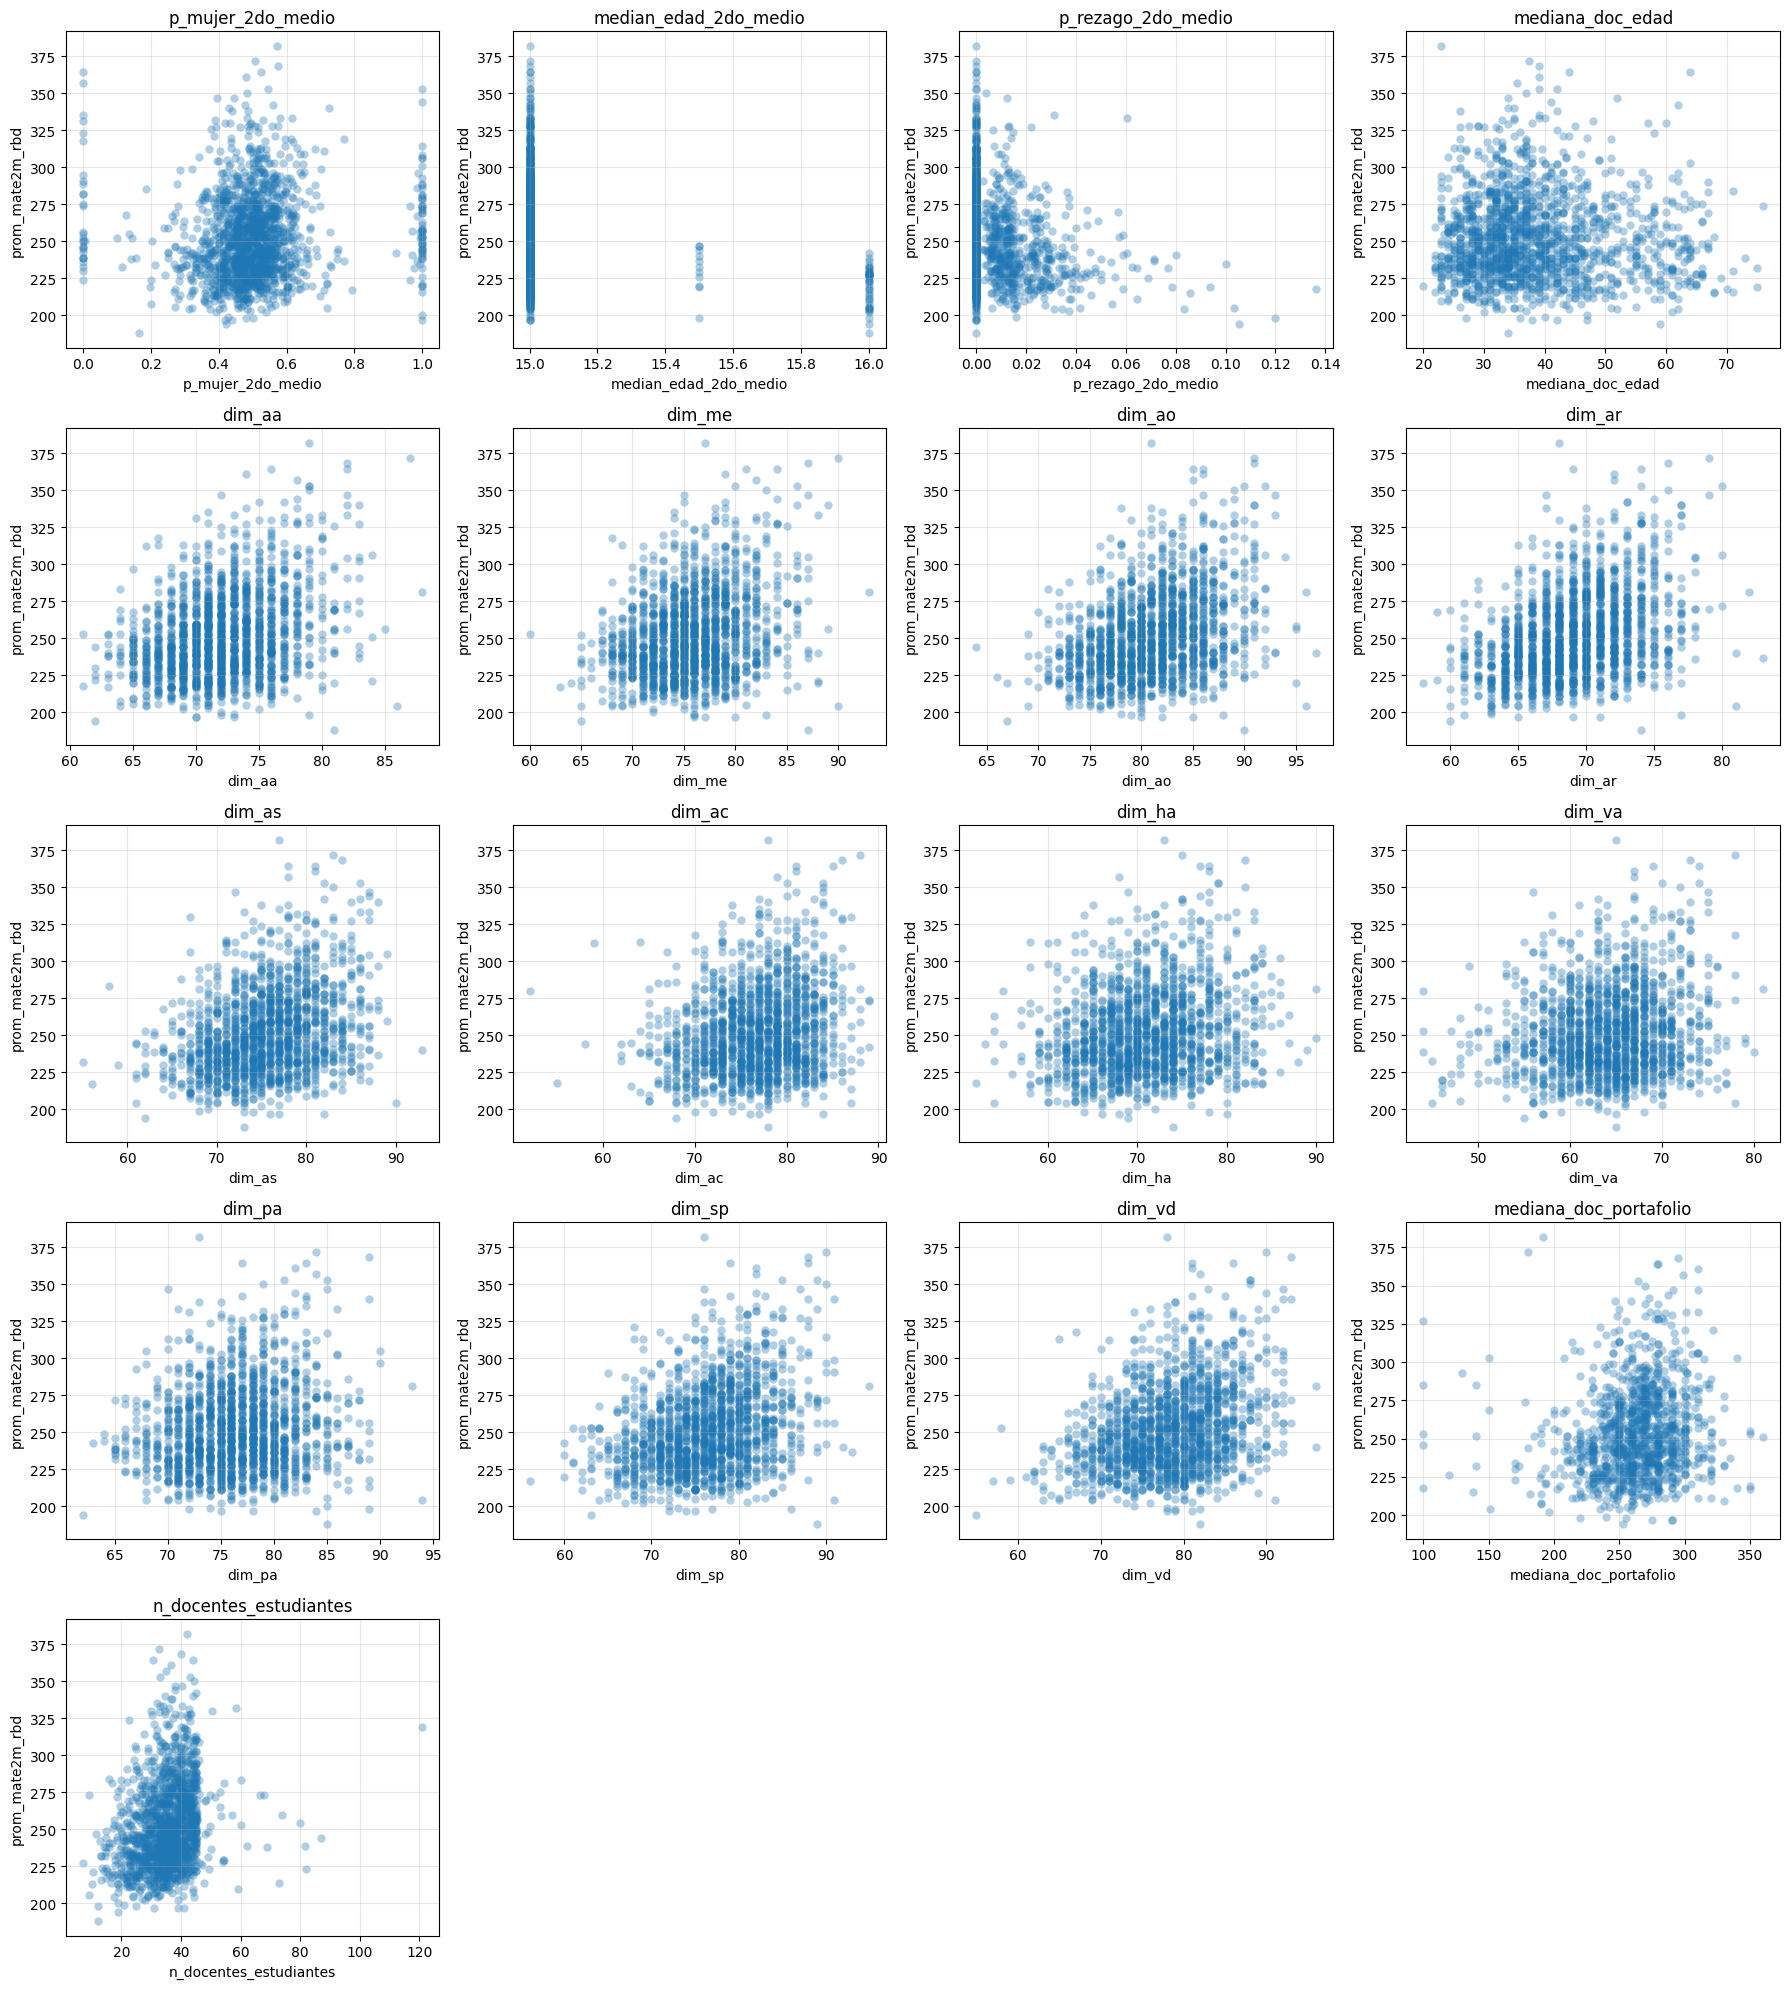

In [37]:
variables = ['p_mujer_2do_medio', 'median_edad_2do_medio', 'p_rezago_2do_medio','mediana_doc_edad',
             'dim_aa','dim_me', 'dim_ao','dim_ar', 'dim_as','dim_ac', 'dim_ha', 'dim_va', 'dim_pa', 'dim_sp', 'dim_vd',
             'mediana_doc_portafolio', 'n_docentes_estudiantes']

n_vars = len(variables)
n_cols = 4
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.atleast_1d(axes).reshape(n_rows, n_cols)

for ax, var in zip(axes.flat, variables):
    subset = rbd_gse_medio_bajo[[var, 'prom_mate2m_rbd']].dropna()
    sns.scatterplot(
        data=subset,
        x=var,
        y='prom_mate2m_rbd',
        alpha=0.35,
        linewidth=0,
        ax=ax
    )
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel('prom_mate2m_rbd')
    ax.grid(True, alpha=0.3)

for ax in axes.flat[len(variables):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()